# Pell Difference-in-Differences Regression

This notebook estimates whether the 2016 Second Chance Pell expansion is associated with changes in two-year recidivism.

The analysis uses the cleaned NCRP file from `01_data_preprocessing.ipynb`. It keeps the treatment definition and sample restrictions used in the submitted report, but the estimates are generated from the current processed dataset. If preprocessing changes, the coefficients can differ from the submitted report.

**Input:** `data/processed/clean_recidivism.csv`  
**Output:** DID model summaries and Pell comparison plots.

## 1. Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

DATA_PATH = Path("../data/processed/clean_recidivism.csv")
PLOTS_DIR = Path("../plots")
PLOTS_DIR.mkdir(exist_ok=True)

## 2. Load Data

Load the cleaned analysis file. The preprocessing notebook owns data construction; this notebook only creates regression variables and estimates models.

In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Rows:    {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
df.head()

Rows:    11,547,985
Columns: 26


,ABT_INMATE_ID,SEX,ADMTYPE,OFFGENERAL,ADMITYR,RELEASEYR,SENTLGTH,OFFDETAIL,RACE,AGEADMIT,AGERELEASE,TIMESRVD,RELTYPE,STATE,STATE_NAME,within_2_yrs,tot_arrest_counts,ABE_Literacy,Secondary,Vocational,College,Automatic_Enrollment,School_District,Sentence_Reduction,Total_Score,policy_tier
0,A012021000000000001,1,1,2,2011,2011,0.0000,7.0000,1.0000,2.0000,2.0000,0,1.0000,1,Alabama,0,1,0.0000,0.0000,0.0000,0.5000,0.0000,0.0000,1.0000,1.5000,Low
1,A012021000000000002,1,1,2,2016,2016,2.0000,8.0000,1.0000,2.0000,2.0000,0,NaN,1,Alabama,1,2,0.0000,0.0000,0.0000,0.5000,0.0000,0.0000,1.0000,1.5000,Low
2,A012021000000000002,1,3,2,2017,2018,2.0000,8.0000,1.0000,2.0000,2.0000,1,2.0000,1,Alabama,0,2,0.0000,0.0000,0.0000,0.5000,0.0000,0.0000,1.0000,1.5000,Low
3,A012021000000000003,1,1,3,2011,2012,2.0000,12.0000,NaN,3.0000,3.0000,0,2.0000,1,Alabama,0,1,0.0000,0.0000,0.0000,0.5000,0.0000,0.0000,1.0000,1.5000,Low
4,A012021000000000004,1,9,2,2003,2007,4.0000,7.0000,1.0000,1.0000,2.0000,2,3.0000,1,Alabama,0,2,0.0000,0.0000,0.0000,0.5000,0.0000,0.0000,1.0000,1.5000,Low


## 3. Define Pell Treatment

`PELL_2016` marks states that participated in the 2016 Second Chance Pell experimental expansion. The list below preserves the treatment definition used in the submitted report because the current processed file does not store `PELL_2016` directly.

In [3]:
pell_2016_states = [
    "Alabama",
    "California",
    "Florida",
    "Illinois",
    "Indiana",
    "Iowa",
    "Massachusetts",
    "Michigan",
    "Minnesota",
    "Nebraska",
    "New Jersey",
    "New York",
    "Ohio",
    "Oklahoma",
    "Pennsylvania",
    "South Carolina",
    "Texas",
    "Washington",
    "Wisconsin",
]

df["PELL_2016"] = df["STATE_NAME"].isin(pell_2016_states).astype(int)
df["post"] = (df["RELEASEYR"] >= 2016).astype(int)
df["treated"] = df["PELL_2016"]
df["post_treated"] = df["post"] * df["treated"]

print(f"Treated states in data: {df.loc[df['treated'] == 1, 'STATE_NAME'].nunique()}")
print(sorted(df.loc[df["treated"] == 1, "STATE_NAME"].dropna().unique()))

df[["STATE_NAME", "RELEASEYR", "PELL_2016", "post", "treated", "post_treated"]].head()

Treated states in data: 19
['Alabama', 'California', 'Florida', 'Illinois', 'Indiana', 'Iowa', 'Massachusetts', 'Michigan', 'Minnesota', 'Nebraska', 'New Jersey', 'New York', 'Ohio', 'Oklahoma', 'Pennsylvania', 'South Carolina', 'Texas', 'Washington', 'Wisconsin']


,STATE_NAME,RELEASEYR,PELL_2016,post,treated,post_treated
0,Alabama,2011,1,0,1,0
1,Alabama,2016,1,1,1,1
2,Alabama,2018,1,1,1,1
3,Alabama,2012,1,0,1,0
4,Alabama,2007,1,0,1,0


## 4. Pre/Post Descriptive Check

Before regression, compare average recidivism by treatment group and period. This is descriptive and does not control for state, year, or individual characteristics.

In [4]:
did_means = (
    df.groupby(["post", "treated"], observed=True)["within_2_yrs"]
    .mean()
    .unstack("treated")
    .rename(index={0: "Pre", 1: "Post"}, columns={0: "Control", 1: "Pell"})
)

did_counts = (
    df.groupby(["post", "treated"], observed=True)["within_2_yrs"]
    .size()
    .unstack("treated")
    .rename(index={0: "Pre", 1: "Post"}, columns={0: "Control", 1: "Pell"})
)

control_drop = did_means.loc["Pre", "Control"] - did_means.loc["Post", "Control"]
pell_drop = did_means.loc["Pre", "Pell"] - did_means.loc["Post", "Pell"]
raw_did = pell_drop - control_drop

print("Mean recidivism:")
display(did_means)
print("\nCell counts:")
display(did_counts)
print(f"\nRaw DID change: {raw_did:.4f}")


Mean recidivism:


treated,Control,Pell
post,,
Pre,0.2530,0.2836
Post,0.1912,0.1624



Cell counts:


treated,Control,Pell
post,,
Pre,2637579,7471299
Post,446747,992360



Raw DID change: 0.0593


## 5. Baseline DID Model

Estimate the simple DID model without fixed effects or individual controls. This is useful as a descriptive starting point, but it should not be treated as the preferred estimate because it does not account for persistent state differences or common year shocks.

In [5]:
model_baseline = smf.ols(
    "within_2_yrs ~ treated + post + post_treated",
    data=df,
).fit()

print(model_baseline.summary())
print(f"Baseline DID estimate: {model_baseline.params['post_treated']:.4f}")

                            OLS Regression Results                            
Dep. Variable:           within_2_yrs   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                 2.734e+04
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        00:20:18   Log-Likelihood:            -6.8657e+06
No. Observations:            11547985   AIC:                         1.373e+07
Df Residuals:                11547981   BIC:                         1.373e+07
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.2530      0.000    937.117   

## 6. State and Year Fixed Effects

Add state fixed effects and release-year fixed effects to account for persistent differences across states and common national time shocks.

In [6]:
model_fe = smf.ols(
    "within_2_yrs ~ post_treated + C(STATE_NAME) + C(RELEASEYR)",
    data=df,
).fit()

print(model_fe.summary())
print(f"FE DID estimate: {model_fe.params['post_treated']:.4f}")

                            OLS Regression Results                            
Dep. Variable:           within_2_yrs   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     3739.
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        00:23:34   Log-Likelihood:            -6.7571e+06
No. Observations:            11547985   AIC:                         1.351e+07
Df Residuals:                11547903   BIC:                         1.352e+07
Df Model:                          81                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

## 7. Clustered Standard Errors

Because treatment varies at the state level, standard errors are clustered by state.

In [7]:
model_fe_cluster = smf.ols(
    "within_2_yrs ~ post_treated + C(STATE_NAME) + C(RELEASEYR)",
    data=df,
).fit(cov_type="cluster", cov_kwds={"groups": df["STATE_NAME"]})

print(model_fe_cluster.summary())
print(f"Clustered FE DID estimate: {model_fe_cluster.params['post_treated']:.4f}")

/Users/temesmacbookair/Development/workspace/Recidivism-Education/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 81, but rank is 36
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:           within_2_yrs   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                 1.301e+12
Date:                Sat, 02 May 2026   Prob (F-statistic):          5.14e-192
Time:                        00:27:20   Log-Likelihood:            -6.7571e+06
No. Observations:            11547985   AIC:                         1.351e+07
Df Residuals:                11547903   BIC:                         1.352e+07
Df Model:                          81                                         
Covariance Type:              cluster                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

/Users/temesmacbookair/Development/workspace/Recidivism-Education/.venv/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


## 8. Parallel Trends Check

Estimate an event-study style model around 2016. Pre-2016 interaction terms are used as a diagnostic for the DID parallel trends assumption.

In [8]:
df["event_time"] = df["RELEASEYR"] - 2016
df_event = df[(df["event_time"] >= -6) & (df["event_time"] <= 6)].copy()

model_event = smf.ols(
    "within_2_yrs ~ treated * C(event_time) + C(STATE_NAME)",
    data=df_event,
).fit(cov_type="cluster", cov_kwds={"groups": df_event["STATE_NAME"]})

print(model_event.summary())

                            OLS Regression Results                            
Dep. Variable:           within_2_yrs   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                -0.0003499
Date:                Sat, 02 May 2026   Prob (F-statistic):               1.00
Time:                        00:27:48   Log-Likelihood:            -2.3673e+06
No. Observations:             4659925   AIC:                         4.735e+06
Df Residuals:                 4659874   BIC:                         4.735e+06
Df Model:                          50                                         
Covariance Type:              cluster                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

/Users/temesmacbookair/Development/workspace/Recidivism-Education/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 50, but rank is 16
  warnings.warn('covariance of constraints does not have full '
/Users/temesmacbookair/Development/workspace/Recidivism-Education/.venv/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


## 9. Analysis Sample with Controls

Apply the same restrictions used in the submitted controlled model:

- exclude sentence length categories `4`, `5`, and `6`
- keep valid age-at-admission categories up to `5`
- restrict release years to `2005-2018`

The 2018 outcome is retained here to match the submitted report. The EDA notebook flags 2018 as right-censored, so a future robustness check should also run the model through 2017.

In [9]:
df_reg = df.copy()
df_reg = df_reg[~df_reg["SENTLGTH"].isin([4, 5, 6])]
df_reg = df_reg[df_reg["AGEADMIT"] <= 5]
df_reg = df_reg[(df_reg["RELEASEYR"] >= 2005) & (df_reg["RELEASEYR"] <= 2018)]

df_reg_model = df_reg.dropna(
    subset=[
        "within_2_yrs",
        "post_treated",
        "STATE_NAME",
        "RELEASEYR",
        "OFFGENERAL",
        "SEX",
        "AGEADMIT",
        "SENTLGTH",
    ]
)

print(f"Full data:       {len(df):,}")
print(f"Restricted data: {len(df_reg):,}")
print(f"Model data:      {len(df_reg_model):,}")

df_reg_model["OFFGENERAL"].value_counts().sort_index()

Full data:       11,547,985
Restricted data: 6,414,037
Model data:      6,361,584


OFFGENERAL
1    1381875
2    1935452
3    1798284
4    1183014
5      38545
9      24414
Name: count, dtype: int64

## 10. DID with Individual Controls

Add offense type, sex, age at admission, and sentence length while retaining state and year fixed effects. This is the main controlled estimate used in the report.

In [10]:
model_controls = smf.ols(
    "within_2_yrs ~ post_treated"
    " + C(STATE_NAME)"
    " + C(RELEASEYR)"
    " + C(OFFGENERAL)"
    " + C(SEX)"
    " + AGEADMIT"
    " + SENTLGTH",
    data=df_reg_model,
).fit(cov_type="cluster", cov_kwds={"groups": df_reg_model["STATE_NAME"]})

print(model_controls.summary())
print(f"Controlled DID estimate: {model_controls.params['post_treated']:.4f}")
print(f"p-value: {model_controls.pvalues['post_treated']:.4f}")

/Users/temesmacbookair/Development/workspace/Recidivism-Education/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 54, but rank is 22
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:           within_2_yrs   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     1523.
Date:                Sat, 02 May 2026   Prob (F-statistic):           2.50e-42
Time:                        00:28:36   Log-Likelihood:            -3.5421e+06
No. Observations:             6361584   AIC:                         7.084e+06
Df Residuals:                 6361529   BIC:                         7.085e+06
Df Model:                          54                                         
Covariance Type:              cluster                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

## 11. Heterogeneity by Offense Type

Interact the DID treatment effect with broad offense categories to inspect whether the Pell association differs by offense type.

In [11]:
model_crime_heterogeneity = smf.ols(
    "within_2_yrs ~ post_treated * C(OFFGENERAL)"
    " + C(STATE_NAME)"
    " + C(RELEASEYR)"
    " + C(SEX)"
    " + AGEADMIT"
    " + SENTLGTH",
    data=df_reg_model,
).fit(cov_type="cluster", cov_kwds={"groups": df_reg_model["STATE_NAME"]})

print(model_crime_heterogeneity.summary())

                            OLS Regression Results                            
Dep. Variable:           within_2_yrs   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     3155.
Date:                Sat, 02 May 2026   Prob (F-statistic):           7.11e-48
Time:                        00:29:22   Log-Likelihood:            -3.5421e+06
No. Observations:             6361584   AIC:                         7.084e+06
Df Residuals:                 6361524   BIC:                         7.085e+06
Df Model:                          59                                         
Covariance Type:              cluster                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

/Users/temesmacbookair/Development/workspace/Recidivism-Education/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 59, but rank is 27
  warnings.warn('covariance of constraints does not have full '


## 12. Report Figures

Create the same pre/post Pell comparison figures used in the report, with values computed from the current data rather than hardcoded.

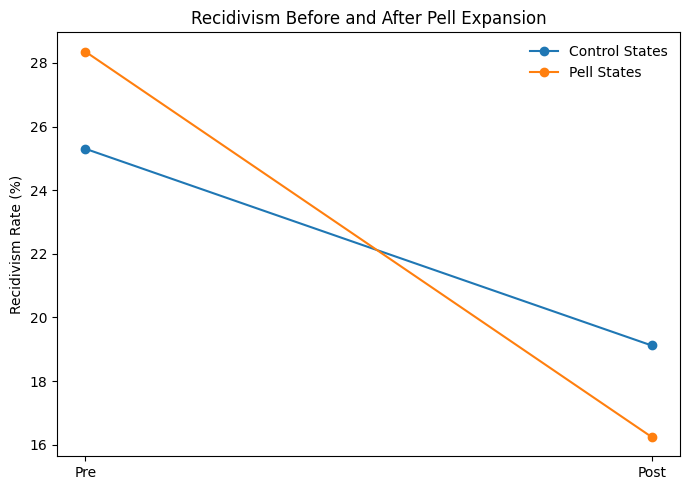

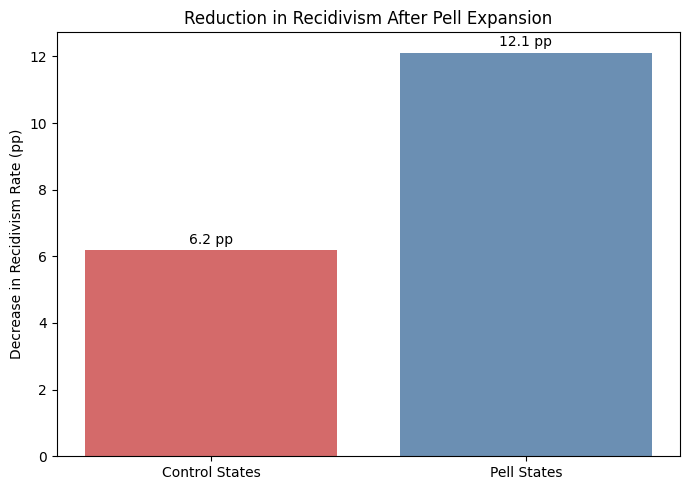

In [12]:
pre_control = did_means.loc["Pre", "Control"] * 100
post_control = did_means.loc["Post", "Control"] * 100
pre_pell = did_means.loc["Pre", "Pell"] * 100
post_pell = did_means.loc["Post", "Pell"] * 100

control_drop = pre_control - post_control
pell_drop = pre_pell - post_pell

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(["Pre", "Post"], [pre_control, post_control], marker="o", label="Control States")
ax.plot(["Pre", "Post"], [pre_pell, post_pell], marker="o", label="Pell States")
ax.set_title("Recidivism Before and After Pell Expansion")
ax.set_ylabel("Recidivism Rate (%)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(["Control States", "Pell States"], [control_drop, pell_drop], color=["#d46a6a", "#6b8fb3"])
ax.set_title("Reduction in Recidivism After Pell Expansion")
ax.set_ylabel("Decrease in Recidivism Rate (pp)")
for i, value in enumerate([control_drop, pell_drop]):
    ax.text(i, value + 0.2, f"{value:.1f} pp", ha="center")
plt.tight_layout()
plt.show()

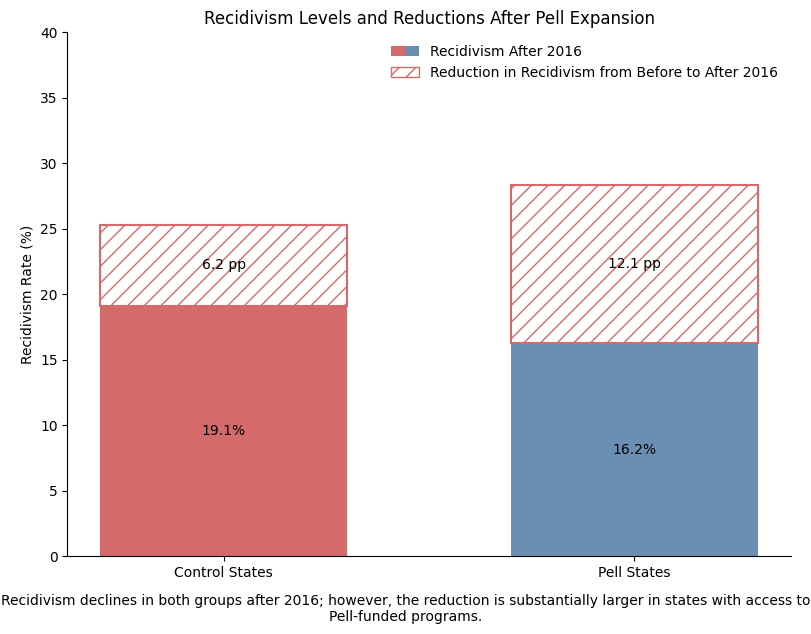

In [13]:
from matplotlib.patches import Patch, Rectangle
from matplotlib.legend_handler import HandlerBase


class HandlerHalfAndHalf(HandlerBase):
    def create_artists(self, legend, orig_handle, x0, y0, width, height, fontsize, trans):
        left = Rectangle((x0, y0), width / 2, height, facecolor=orig_handle[0].get_facecolor(), transform=trans)
        right = Rectangle((x0 + width / 2, y0), width / 2, height, facecolor=orig_handle[1].get_facecolor(), transform=trans)
        return [left, right]


x = np.arange(2)
labels = ["Control States", "Pell States"]
red = "#d46a6a"
blue = "#6b8fb3"

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x[0], post_control, color=red, width=0.6)
ax.bar(x[1], post_pell, color=blue, width=0.6)

ax.bar(x[0], control_drop, bottom=post_control, width=0.6, hatch="//", edgecolor=red, color="none", linewidth=1.5)
ax.bar(x[1], pell_drop, bottom=post_pell, width=0.6, hatch="//", edgecolor=red, color="none", linewidth=1.5)

ax.text(x[0], post_control / 2, f"{post_control:.1f}%", ha="center", va="center")
ax.text(x[1], post_pell / 2, f"{post_pell:.1f}%", ha="center", va="center")
ax.text(x[0], post_control + control_drop / 2, f"{control_drop:.1f} pp", ha="center", va="center")
ax.text(x[1], post_pell + pell_drop / 2, f"{pell_drop:.1f} pp", ha="center", va="center")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Recidivism Rate (%)")
ax.set_title("Recidivism Levels and Reductions After Pell Expansion")
ax.set_ylim(0, 40)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

recid_handle = (Patch(facecolor=red), Patch(facecolor=blue))
reduction_handle = Patch(facecolor="none", edgecolor=red, hatch="//")
ax.legend(
    [recid_handle, reduction_handle],
    ["Recidivism After 2016", "Reduction in Recidivism from Before to After 2016"],
    handler_map={tuple: HandlerHalfAndHalf()},
    frameon=False,
)

caption = (
    "Recidivism declines in both groups after 2016; however, the reduction is substantially "
    "larger in states with access to Pell-funded programs."
)
fig.text(0.5, -0.04, caption, wrap=True, ha="center")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "pell_plot_05.png", dpi=300, bbox_inches="tight")
plt.savefig(PLOTS_DIR / "pell_plot_errorbar.png", dpi=300, bbox_inches="tight")
plt.show()

## 13. Summary

The preferred specification is the model with state fixed effects, year fixed effects, individual controls, and state-clustered standard errors.

Using the current processed dataset, the controlled DID estimate is about a **2.4 percentage point reduction** for Pell states after 2016, and it is not statistically significant after clustering (p=0.25). The summary table below is the source of truth for the current run.

In [14]:
summary_results = pd.DataFrame(
    {
        "model": ["Baseline", "State + year FE", "Clustered FE", "Controls + clustered FE"],
        "post_treated_coef": [
            model_baseline.params["post_treated"],
            model_fe.params["post_treated"],
            model_fe_cluster.params["post_treated"],
            model_controls.params["post_treated"],
        ],
        "p_value": [
            model_baseline.pvalues["post_treated"],
            model_fe.pvalues["post_treated"],
            model_fe_cluster.pvalues["post_treated"],
            model_controls.pvalues["post_treated"],
        ],
    }
)
summary_results

,model,post_treated_coef,p_value
0,Baseline,-0.0593,0.0000
1,State + year FE,-0.0333,0.0000
2,Clustered FE,-0.0333,0.1438
3,Controls + clustered FE,-0.0240,0.2465
